In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,CIFAR100


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # 隨機裁剪
    transforms.RandomHorizontalFlip(),     # 隨機水平翻轉
    transforms.RandomRotation(15),         # 隨機旋轉
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),  # CIFAR-100 的均值和標準差
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

In [3]:
model_algo="alexnet"

In [4]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [5]:
# CIFAR-100 資料集
trainset = CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainset=CifarDataset(trainset)


validset = CIFAR10(root='./data', train=False, download=True, transform=transform_test)
validset=CifarDataset(validset)

Files already downloaded and verified
Files already downloaded and verified


In [6]:
# images=CifarDataset(cifar100_train)
# generator = torch.Generator()
# generator.manual_seed(125)

# size = len(images)
# valid_size = int(0.2 * size)

# train_size = int(size -valid_size)

# trainset,validset = random_split(images, (train_size, valid_size), generator=generator)

In [7]:
# valid_size

In [8]:
# train_size

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

Epoch=0,train_loss=1.7126142879867554,train_accu=34.254%
Epoch=0,valid_loss=1.6797873655319213,valid_accu=35.91%
0
Epoch=1,train_loss=1.570676174468994,train_accu=41.922%
Epoch=1,valid_loss=1.5273801208496094,valid_accu=43.28%
0
Epoch=2,train_loss=1.4069209090805053,train_accu=47.774%
Epoch=2,valid_loss=1.3743444988250733,valid_accu=49.419999999999995%
0
Epoch=3,train_loss=1.3448454278945923,train_accu=50.242%
Epoch=3,valid_loss=1.2696760665893554,valid_accu=53.1%
0
Epoch=4,train_loss=1.303575036315918,train_accu=52.432%
Epoch=4,valid_loss=1.1988536520957946,valid_accu=56.10000000000001%
0
Epoch=5,train_loss=1.198313283519745,train_accu=56.182%
Epoch=5,valid_loss=1.1348048973083495,valid_accu=58.440000000000005%
0
Epoch=6,train_loss=1.2094292343139648,train_accu=56.152%
Epoch=6,valid_loss=1.123341914176941,valid_accu=59.29%
0
Epoch=7,train_loss=1.0939753899765015,train_accu=60.041999999999994%
Epoch=7,valid_loss=1.031664479827881,valid_accu=62.949999999999996%
0
Epoch=8,train_loss=1.07

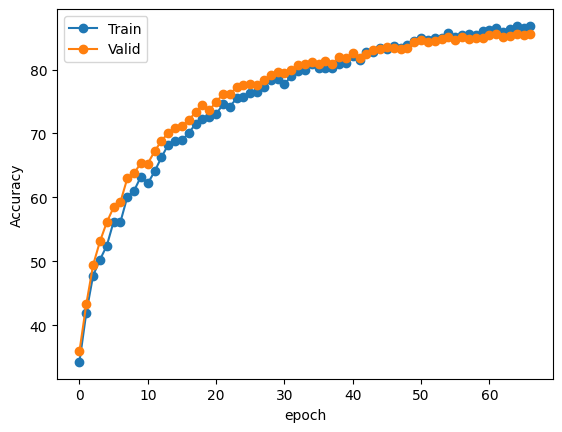

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",100)
# model_0 = torch.load(f'model_{model_algo}_0_85.pth')

In [11]:
train_size=len(trainset)
valid_size=len(validset)
train_size,valid_size

(50000, 10000)

In [12]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.3825929224348068, 0.8634)

In [13]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.44244295160770414, 0.8555)

In [14]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [15]:
each_accu=p
each_accu=each_accu.sort_values(ascending=True)
each_accu

cat           0.6950
dog           0.7916
bird          0.8046
deer          0.8488
horse         0.8924
frog          0.8988
airplane      0.8990
truck         0.9062
ship          0.9450
automobile    0.9526
dtype: float64

In [16]:
each_f1=2*p*r/(p+r)
each_f1

airplane      0.887288
automobile    0.942142
bird          0.819766
cat           0.719015
deer          0.848206
dog           0.782523
frog          0.894684
horse         0.883389
ship          0.930027
truck         0.920561
dtype: float64

In [17]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements[:N], top_positions[:N]

In [18]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=4)

Top 4 Elements:
[0.2456 0.075  0.0678 0.067 ]
Top 4 Positions:
[(5, 3), (3, 2), (6, 3), (4, 2)]


In [19]:
unique_elements = set()

# 遍历所有的元组，并将每个元素添加到集合中
for pair in top_positions:
    unique_elements.update(pair)
    if(len(unique_elements)>=5):
        break

unique_list = list(unique_elements)

print(len(unique_list))    

5


In [20]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classf1',5)

if(split_mode[0]=='classf1'):
    targetF=[x  for x in each_f1.nsmallest(split_mode[1]).index.map(trainset.classess)]
    split=(split_mode[0],targetF)
elif(split_mode[0]=='classaccu'):
    targetF=[x  for x in each_accu.nsmallest(split_mode[1]).index.map(trainset.classess)]
    split=(split_mode[0],targetF)
else:
    split=split_mode

indexF,indexT=split_data(model_0,train_dl,split)

Fdataset=Subset(trainset, indexF)
Tdataset=Subset(trainset, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(25000, 25000)

In [21]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split)
len(indexF_v),len(indexT_v)

(5000, 5000)

In [22]:
# d_data,d_target=decision_split(train_dl,model_0)
# d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [23]:
# decisionset=DecisionDataset(d_data,d_target)
# decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [24]:
# class_counts = [0, 0]
# for _,_,label,_ in trainset:
#     class_counts[label] +=1

In [25]:
# # 计算每个类别的权重
# class_weights = [1.0 / count for count in class_counts]
# weights = torch.FloatTensor(class_weights).cuda()

In [26]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,model_0=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[-1]=nn.Linear(model.classifier[-1].in_features,2)

    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[-1]=nn.Linear(model.classifier[-1].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.classes))

    # if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
    #     model_fc_layer=model.fc
    # else:
    #     model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
       
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)

    elif(data_name=='0'):
        optim = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)

    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4, weight_decay=5e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.12886958224773407,train_accu=94.998%
Epoch=0,valid_loss=0.12417452933192254,valid_accu=95.08%
0
Epoch=1,train_loss=0.12799695050656795,train_accu=94.87400000000001%
Epoch=1,valid_loss=0.12582064835727214,valid_accu=95.07%
EarlyStopping counter: 1 out of 5
Epoch=2,train_loss=0.11409475158303976,train_accu=95.542%
Epoch=2,valid_loss=0.11639945157244802,valid_accu=95.49%
0
Epoch=3,train_loss=0.12632980013370515,train_accu=95.012%
Epoch=3,valid_loss=0.13087228930592537,valid_accu=95.05%
EarlyStopping counter: 1 out of 5
Epoch=4,train_loss=0.10957327009677886,train_accu=95.49%
Epoch=4,valid_loss=0.11528532436788082,valid_accu=95.74000000000001%
0
Epoch=5,train_loss=0.10556297896504402,train_accu=95.834%
Epoch=5,valid_loss=0.11120100953876973,valid_accu=95.54%
EarlyStopping counter: 1 out of 5
Epoch=6,train_loss=0.10465590744495391,train_accu=95.944%
Epoch=6,valid_loss=0.11108129065334797,valid_accu=95.67%
EarlyStopping counter: 2 out of 5
Learning rate reduced by 10%8e-

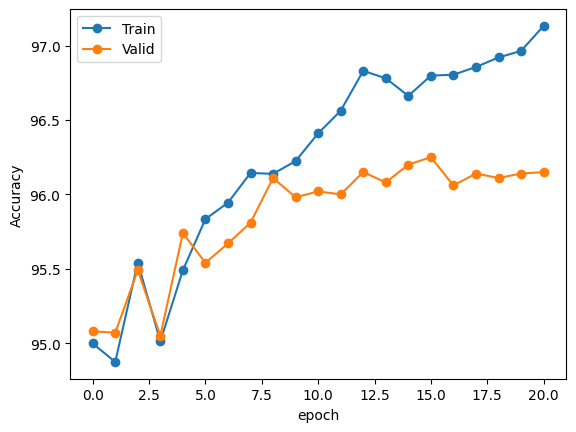

In [27]:
from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
# # decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
# decision_v_dl = DataLoader(decisionset_v, batch_size=32)
# train_dl=DataLoader(trainset, batch_size=32,sampler=ImbalancedDatasetSampler(trainset))
model_decision=model_train(model_algo,train_dl,valid_dl,"decision",100,model_0=model_0)
# model_decision = torch.load(f'model_{model_algo}_decision_24.pth')

In [28]:
Fdataset_v=Subset(validset, indexF_v)
Tdataset_v=Subset(validset, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.18161496468782426,train_accu=93.792%
Epoch=0,valid_loss=0.2069062207132578,valid_accu=93.38%
0
Epoch=1,train_loss=0.16571323791384696,train_accu=94.21199999999999%
Epoch=1,valid_loss=0.20174222245663403,valid_accu=93.54%
0
Epoch=2,train_loss=0.17105139898359775,train_accu=93.96799999999999%
Epoch=2,valid_loss=0.2001361613512039,valid_accu=93.58%
0
Epoch=3,train_loss=0.1586380188024044,train_accu=94.46%
Epoch=3,valid_loss=0.19067937409728766,valid_accu=93.62%
0
Epoch=4,train_loss=0.1586775428557396,train_accu=94.52000000000001%
Epoch=4,valid_loss=0.19032885530889035,valid_accu=93.74%
0
Epoch=5,train_loss=0.1525270132780075,train_accu=94.49600000000001%
Epoch=5,valid_loss=0.18294305441975595,valid_accu=93.86%
0
Epoch=6,train_loss=0.15177753688514234,train_accu=94.472%
Epoch=6,valid_loss=0.18610661772489548,valid_accu=94.06%
0
Epoch=7,train_loss=0.16104574298262597,train_accu=94.26400000000001%
Epoch=7,valid_loss=0.18819288389272987,valid_accu=93.88%
EarlyStopping cou

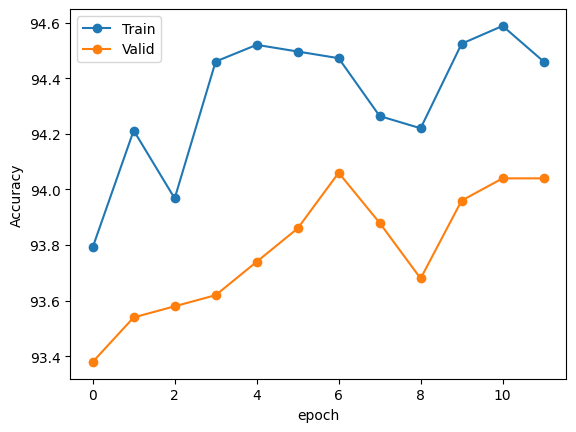

In [29]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",100,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.49578760927200316,train_accu=82.15599999999999%
Epoch=0,valid_loss=0.5089914198875427,valid_accu=82.14%
0
Epoch=1,train_loss=0.4745907949733734,train_accu=82.75200000000001%
Epoch=1,valid_loss=0.4994917760848999,valid_accu=82.3%
0
Epoch=2,train_loss=0.4613263936328888,train_accu=83.016%
Epoch=2,valid_loss=0.48904634914398193,valid_accu=82.8%
0
Epoch=3,train_loss=0.45839316820144654,train_accu=83.112%
Epoch=3,valid_loss=0.49135836429595947,valid_accu=82.64%
EarlyStopping counter: 1 out of 5
Epoch=4,train_loss=0.4519088165283203,train_accu=83.47200000000001%
Epoch=4,valid_loss=0.4851926818847656,valid_accu=83.06%
0
Epoch=5,train_loss=0.451678319568634,train_accu=83.392%
Epoch=5,valid_loss=0.4858393293619156,valid_accu=82.98%
EarlyStopping counter: 1 out of 5
Epoch=6,train_loss=0.45003895635604857,train_accu=83.43599999999999%
Epoch=6,valid_loss=0.480168604183197,valid_accu=83.12%
0
Epoch=7,train_loss=0.45326245839118956,train_accu=83.47200000000001%
Epoch=7,valid_los

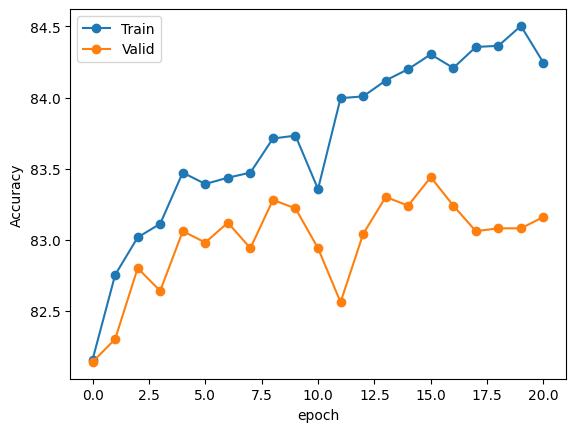

In [30]:
#訓練模型T、F、decision
model_F=model_train(model_algo,Fdl,Fdl_v,"F",100,model_0=model_0)
# model_F=torch.load(f'model_{model_algo}_F_1.pth')

In [31]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,train_dl,len(trainset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.08479625660270453, 0.9672)

In [32]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,valid_dl,len(validset),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.1031249545544386, 0.9625)

In [33]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.15775591259121896, 0.94336)

In [34]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.42753852635383605, 0.84064)

In [35]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.18610661747157572, 0.9406)

In [36]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.4730968500614166, 0.8344)

In [37]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.2933968709683418, 0.89284, 25000)

In [38]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.3296017226457596, 0.8875, 5000)

In [39]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision,decision_mode=None):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    model_0.eval()
    model_T.eval()
    model_F.eval()
    model_decision.eval()

    with torch.no_grad():
        for data,target,decision_target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)

            for d,t in zip(data,target):
                
                out_d=model_decision(d.unsqueeze(0))
                _, pred= torch.max(out_d, dim = 1)

                out=model_0(d.unsqueeze(0))
                _, pred_0= torch.max(out, dim = 1)

                if(decision_mode=='model'):
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                elif(decision_mode=='softmax_0'):
                    out_0=model_0(d.unsqueeze(0))
                    softmax_0 = torch.max(torch.softmax(out_0, dim=1)).item()

                    if(softmax_0<0.8):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='softmax_tf'):
                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_F>softmax_T):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='model+softmax_d'):

                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_d = torch.max(torch.softmax(out_d, dim=1)).item()

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_d<0.9):
                        if(softmax_F>softmax_T):
                            outputs.append(out_F)
                            sum_F+=1
                        else:
                            outputs.append(out_T)
                            sum_T+=1
                    else:
                        if(pred==0):
                            outputs.append(model_F(d.unsqueeze(0)))
                            sum_F+=1
                        else:
                            outputs.append(model_T(d.unsqueeze(0)))
                            sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [40]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_train_loss,total_train_accu,sum_F,sum_T

(0.6275239449214935, 0.8666, 25412, 24588)

In [41]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='model')
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.7754080730438232, 0.8577, 5059, 4941)

In [42]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [43]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split}')
df

split_mode = ('classf1', [3, 5, 2, 4, 7])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.382593,0.86340,0.442443,0.8555
1,Model_Decision,0.084796,0.96720,0.103125,0.9625
2,Model_T,0.157756,0.94336,0.186107,0.9406
3,Model_F,0.427539,0.84064,0.473097,0.8344
4,Total_Model,0.627524,0.86660,0.775408,0.8577
5,Total_Model_with_perfect_decision,0.293397,0.89284,0.329602,0.8875


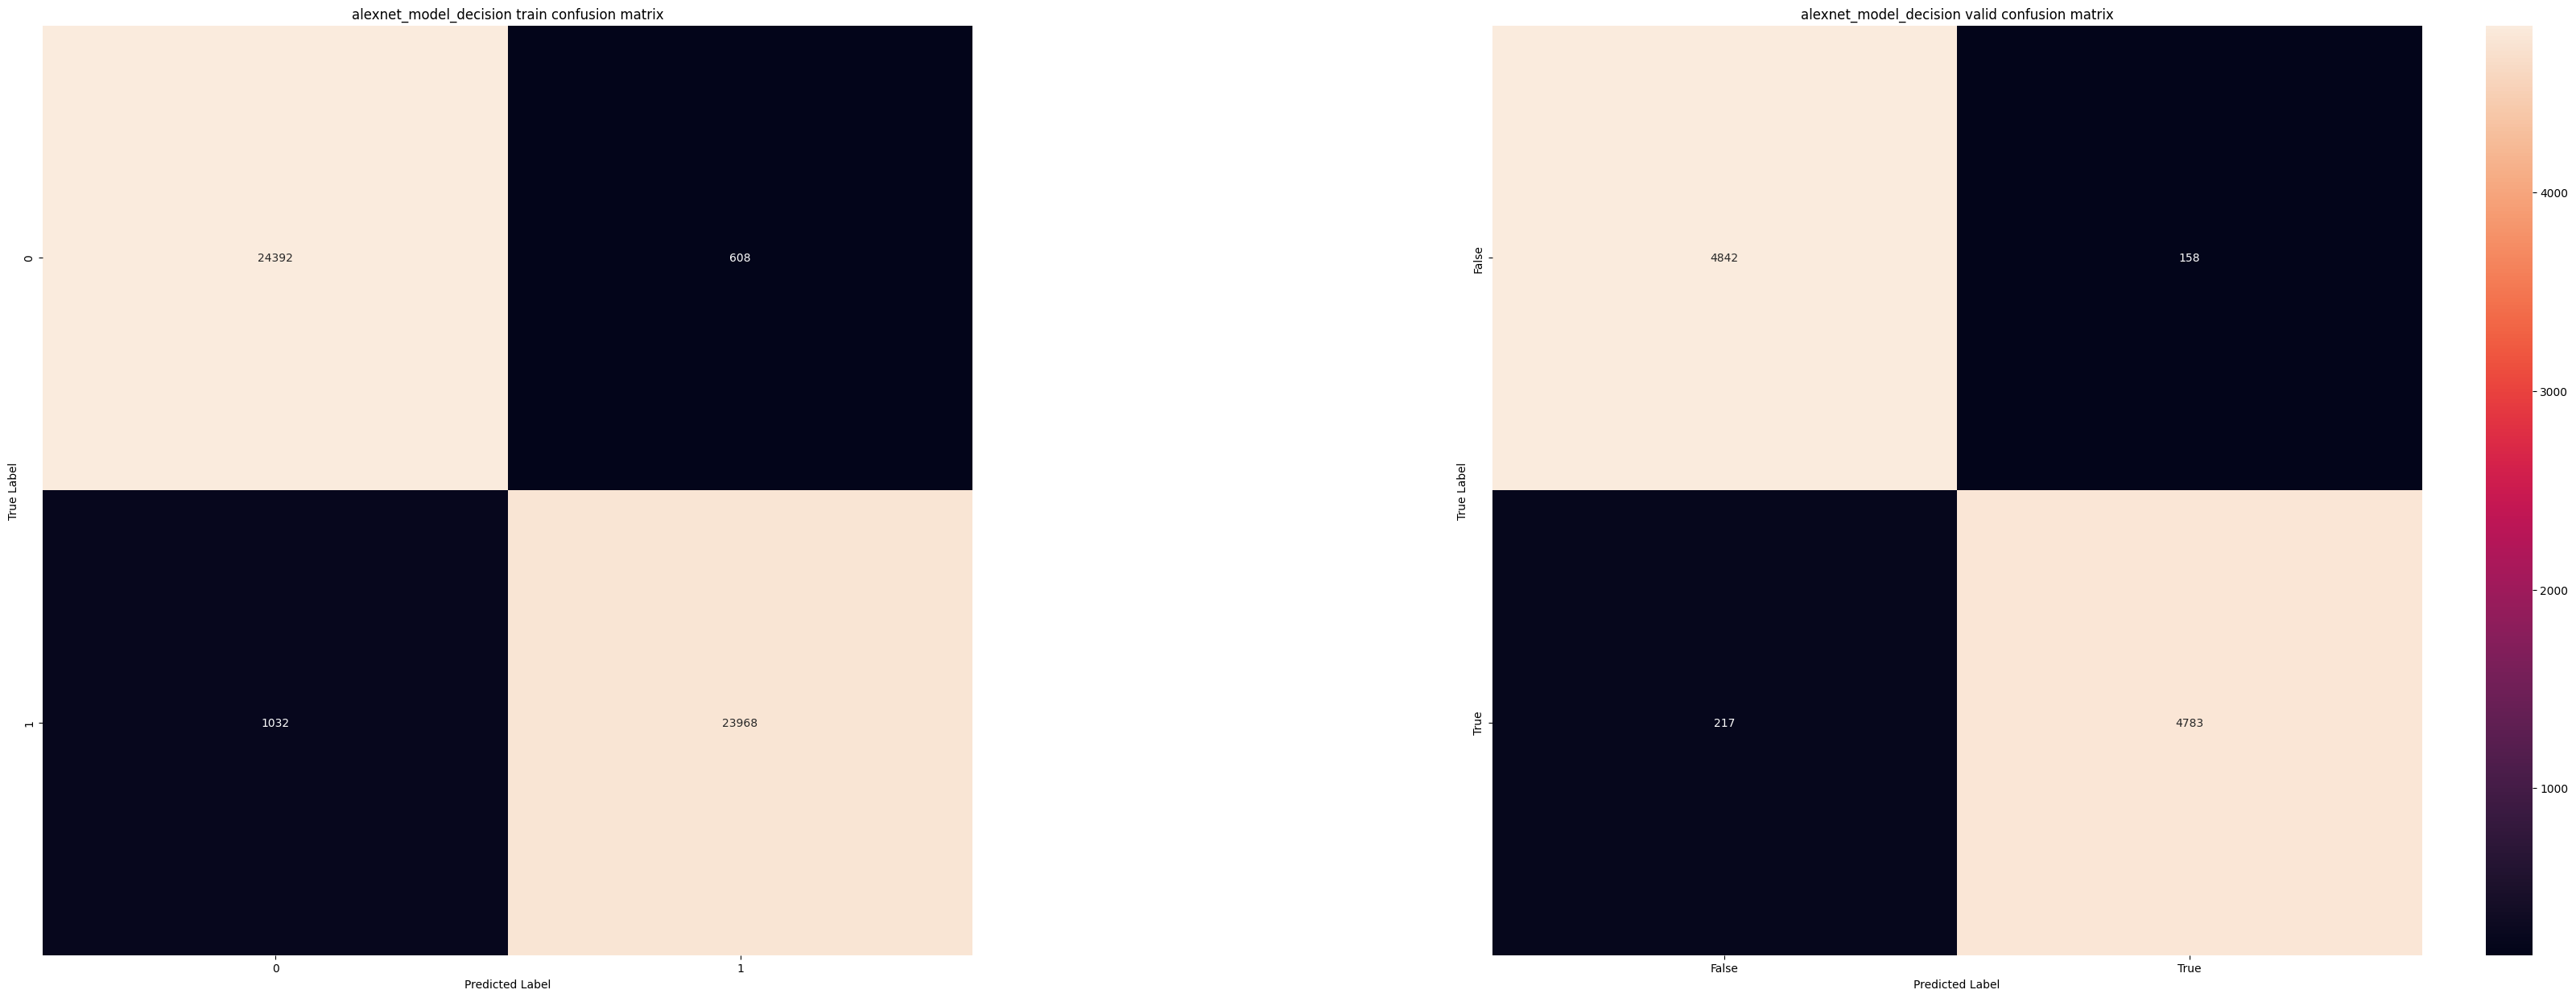

In [44]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

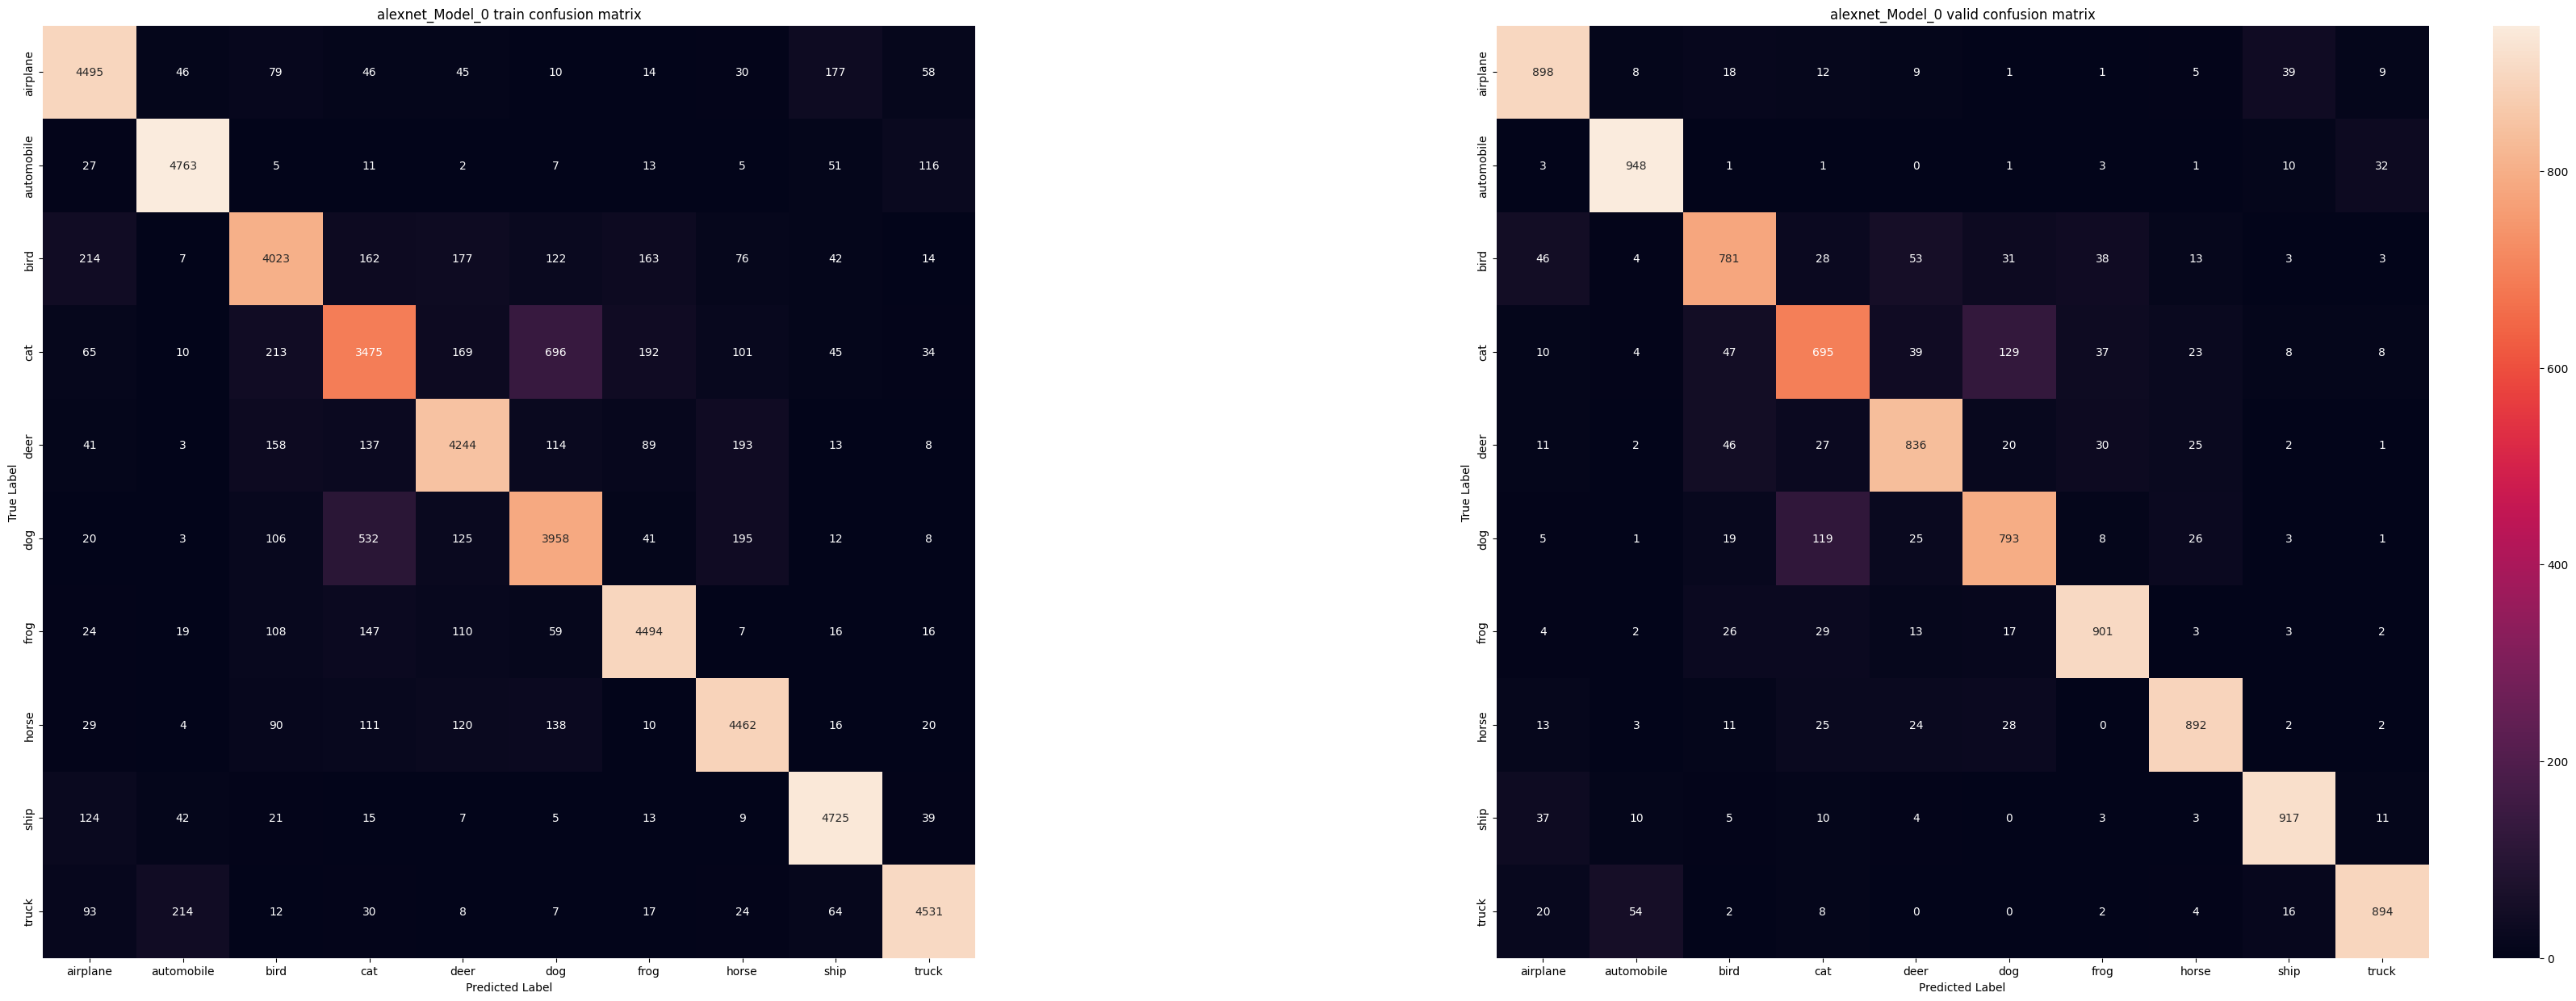

In [45]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

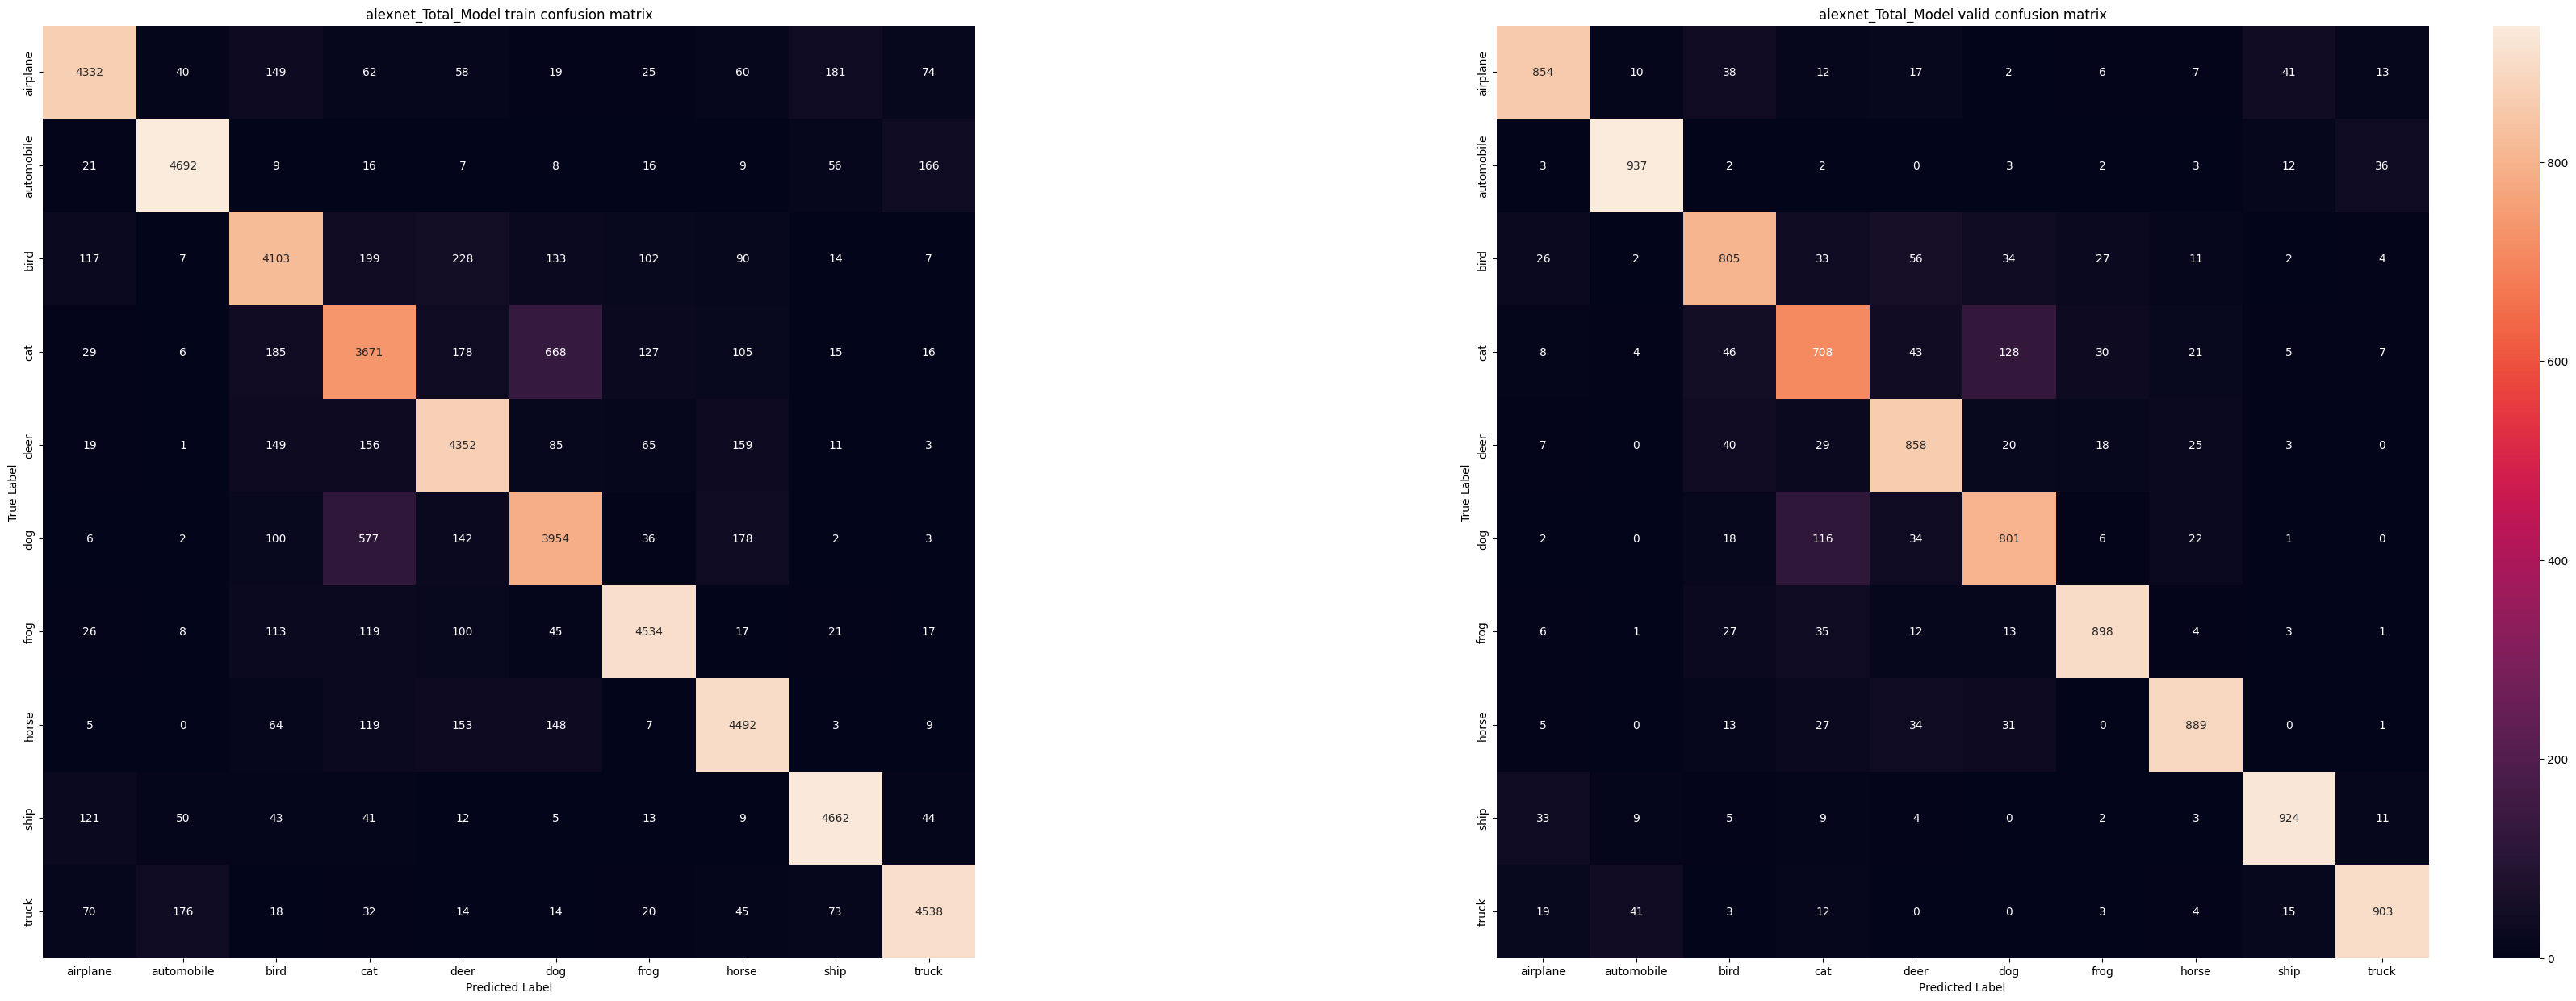

In [46]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

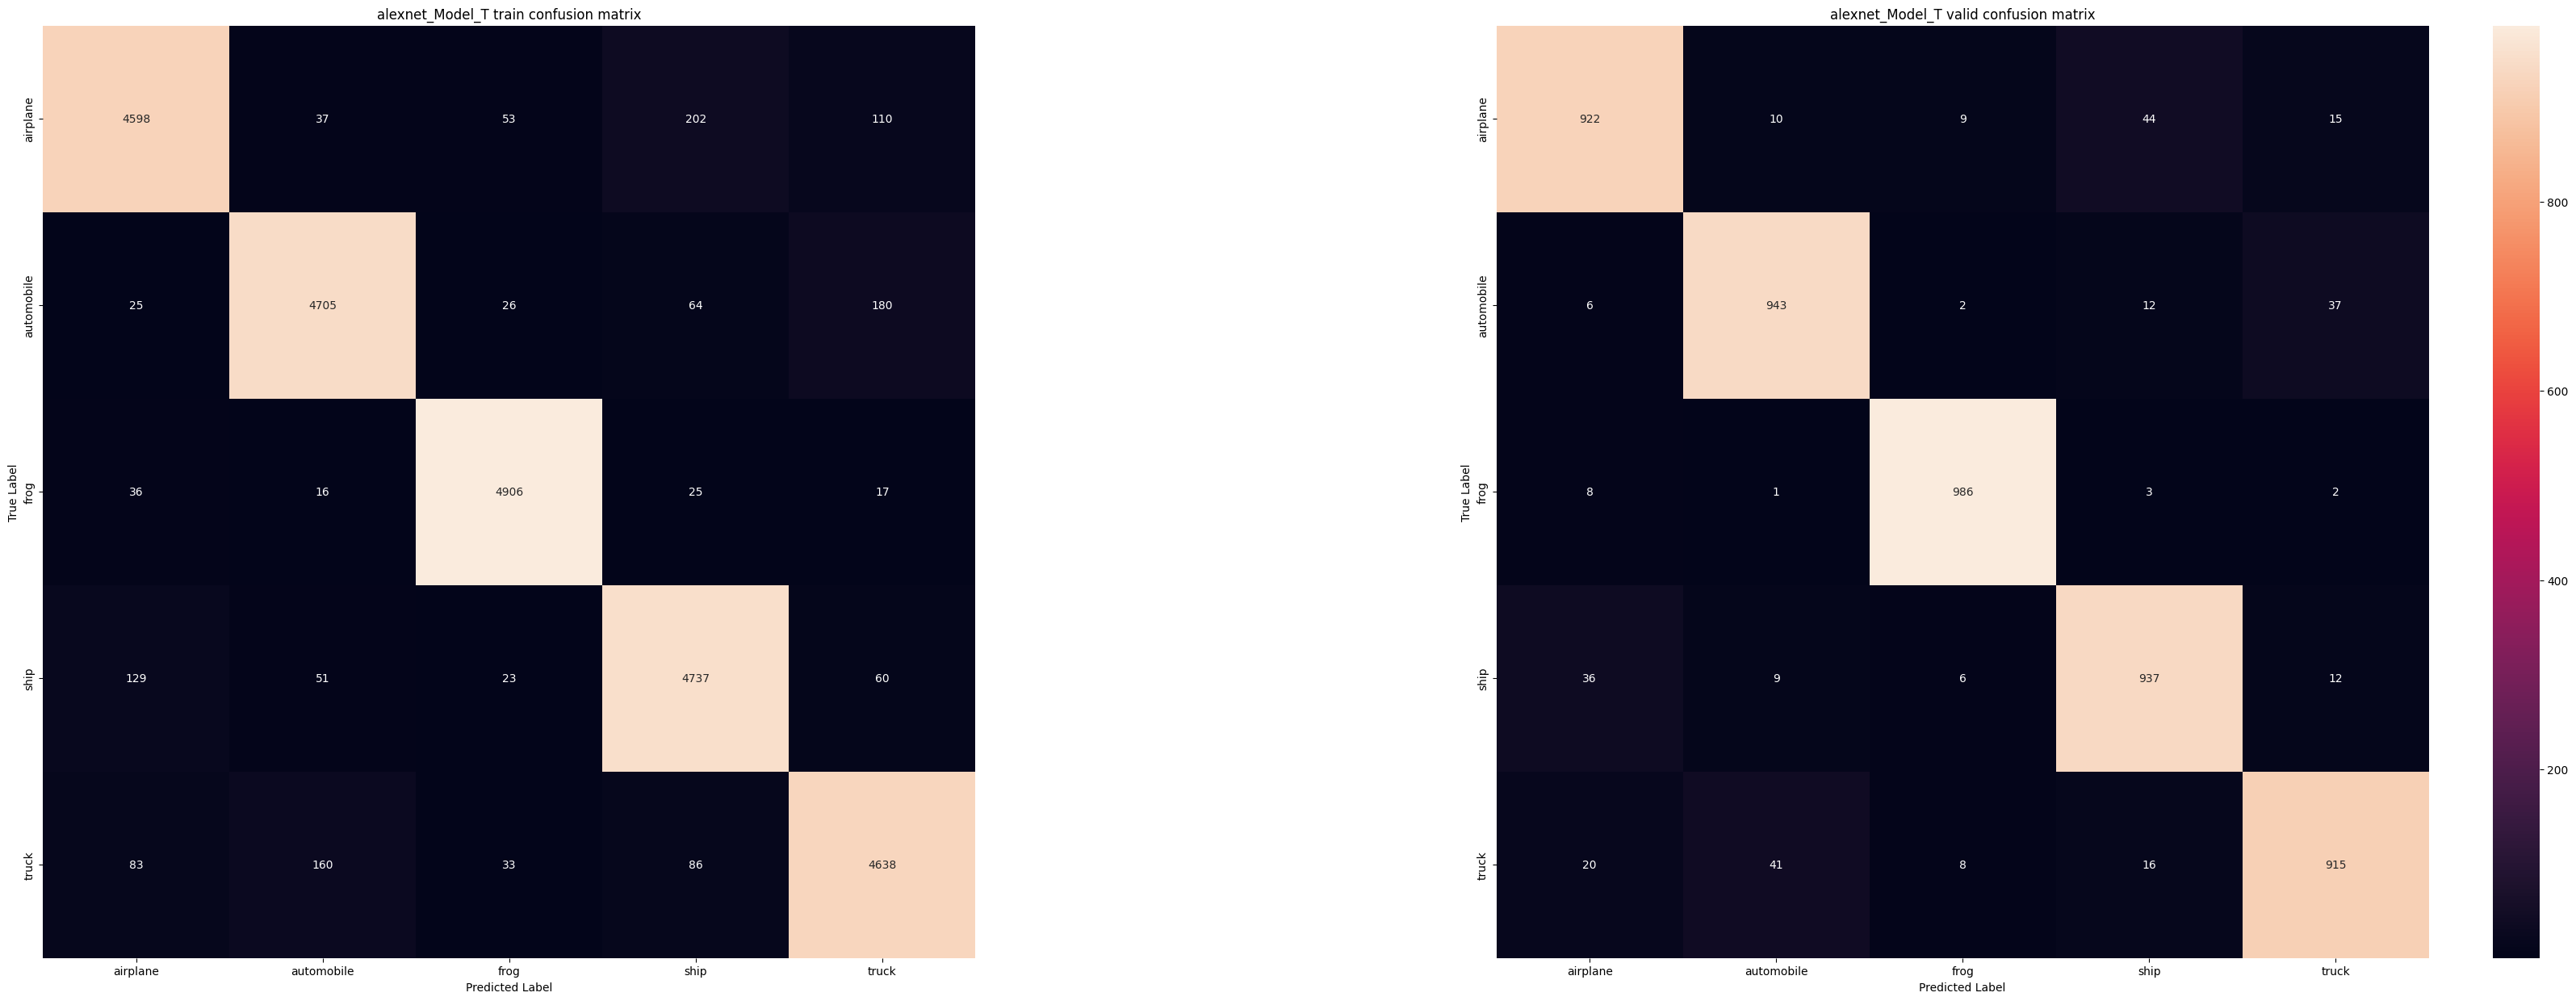

In [47]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

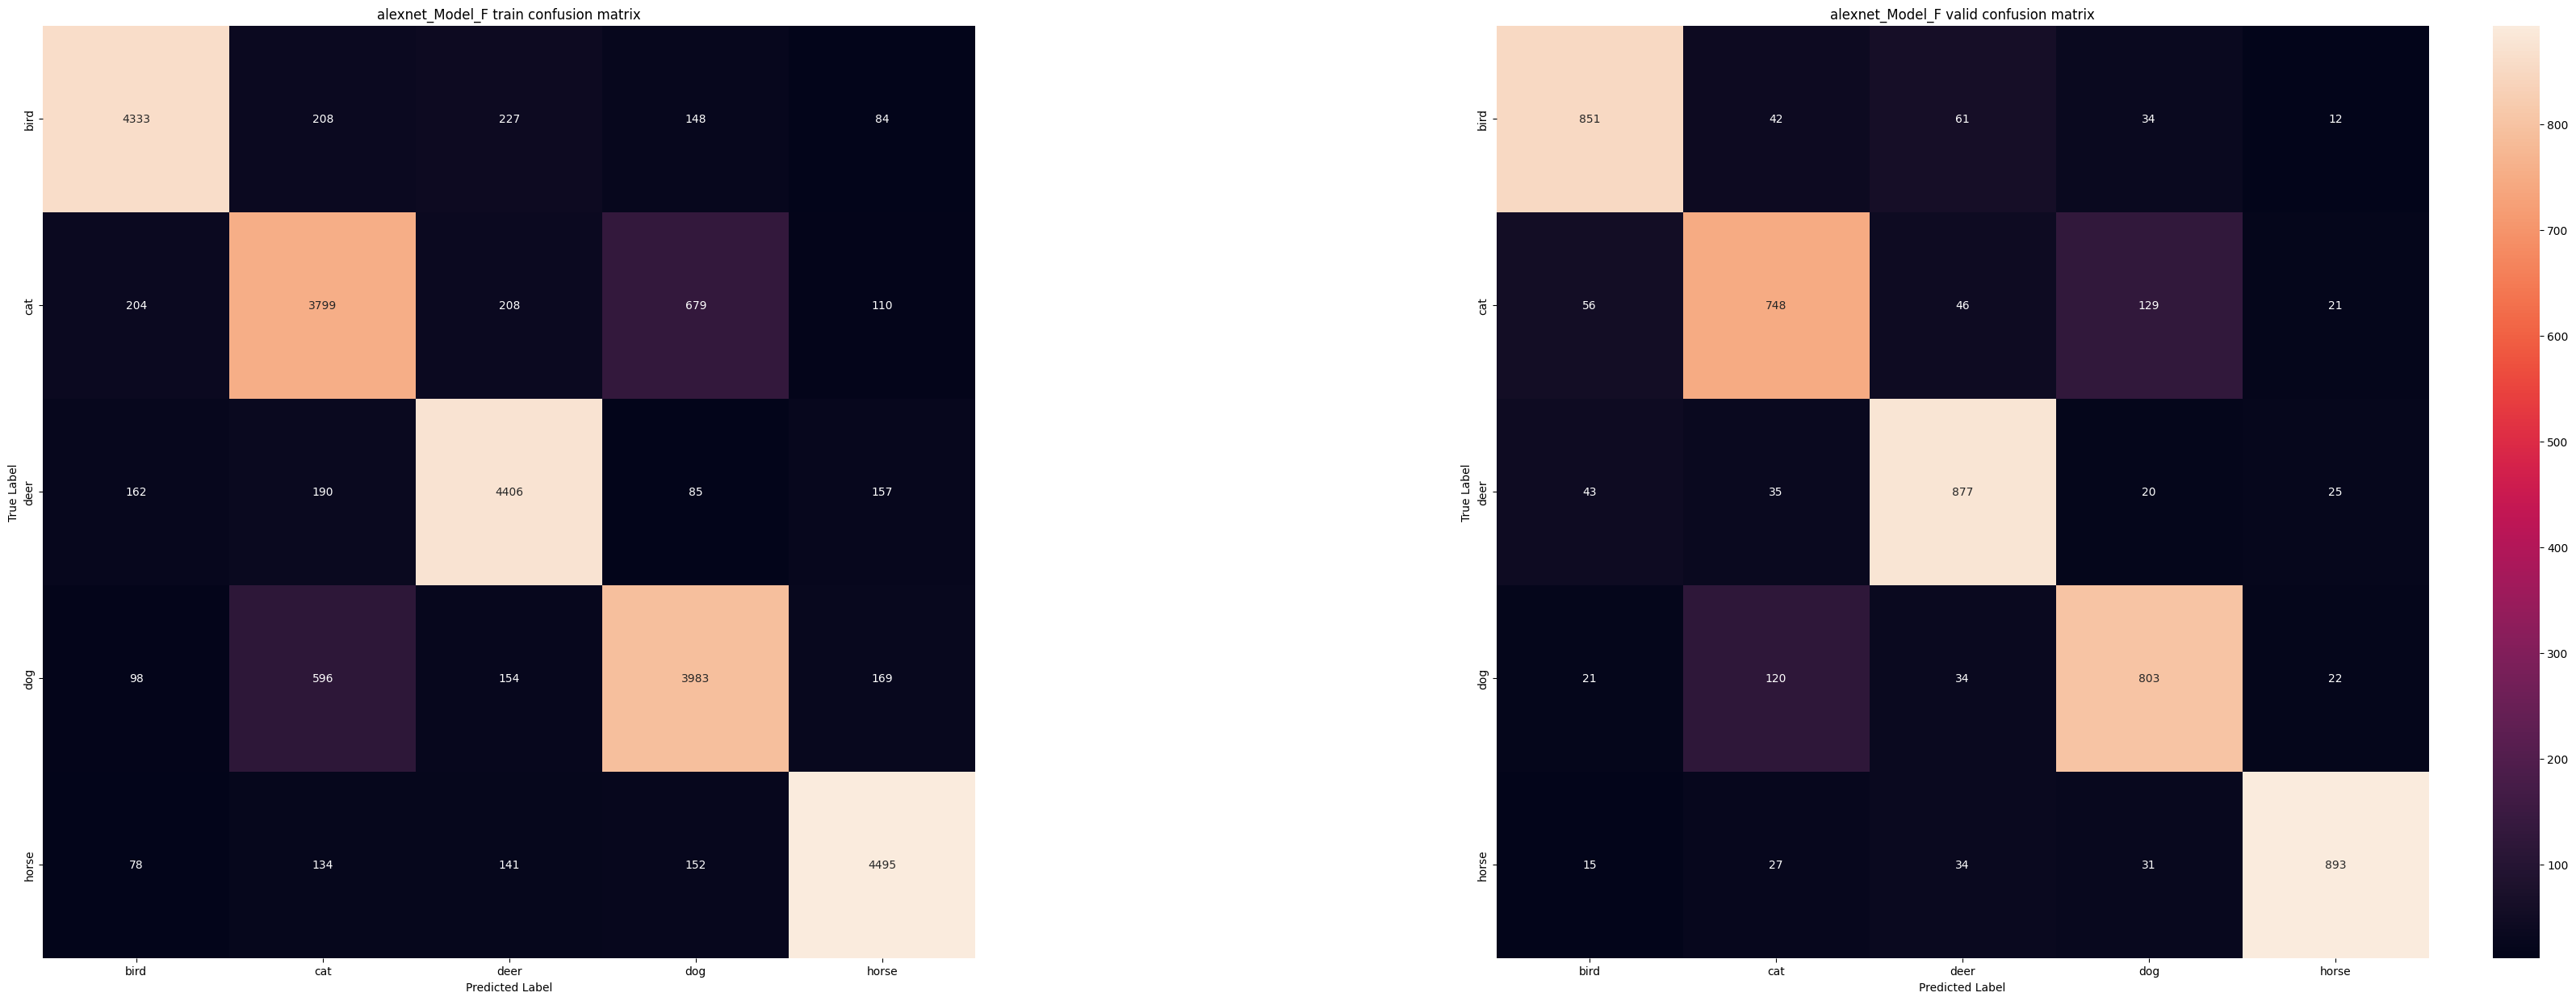

In [48]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [49]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,_,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.flag[idx],
                    'Match_d': bool(pred_decision) == data_dl.dataset.flag[idx]
                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [50]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
0,26128,2,2,8,8,0.809172,0.882856,0.397007,0.968087,True,False,False,False,False,True
1,31010,9,7,9,1,0.752917,0.589428,0.580982,0.991899,False,True,False,True,True,True
2,37712,0,2,0,0,0.451623,0.654777,0.648236,0.999918,False,True,True,True,True,True
3,26455,3,3,6,5,0.519426,0.902426,0.557058,0.995189,True,False,False,False,False,True
4,8389,1,7,1,1,0.373363,0.996484,0.997975,0.999999,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,6458,3,3,0,3,0.557678,0.554810,0.414893,0.702745,True,False,True,False,False,True
49996,7573,0,2,0,0,0.987602,0.999864,0.999732,0.999958,False,True,True,True,True,True
49997,16566,5,3,6,6,0.548111,0.985126,0.364783,0.880549,False,False,False,False,False,True
49998,46457,2,2,6,6,0.857137,0.999961,0.893162,0.815875,True,False,False,True,False,False


In [51]:
df_results[(df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
45,43933,6,4,6,6,0.817283,0.999902,0.578727,0.892411,False,True,True,True,True,True
62,17112,1,3,1,1,0.860157,0.519680,0.531758,0.604790,False,True,True,False,True,False
72,46662,9,7,9,9,0.891840,0.850373,0.548145,0.845675,False,True,True,True,True,True
75,16561,3,3,6,3,0.929115,0.998594,0.878715,0.812535,True,False,True,False,False,True
79,24811,8,4,8,8,0.772009,0.960432,0.963857,0.690590,False,True,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49960,24086,9,3,9,9,0.720868,0.972192,0.920470,0.540820,False,True,True,True,True,True
49969,46935,0,2,0,0,0.887476,0.986039,0.922400,0.891240,False,True,True,True,True,True
49995,6458,3,3,0,3,0.557678,0.554810,0.414893,0.702745,True,False,True,False,False,True
49997,16566,5,3,6,6,0.548111,0.985126,0.364783,0.880549,False,False,False,False,False,True


In [52]:
df_results[(df_results['Decision']!=df_results['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
62,17112,1,3,1,1,0.860157,0.519680,0.531758,0.604790,False,True,True,False,True,False
79,24811,8,4,8,8,0.772009,0.960432,0.963857,0.690590,False,True,True,False,True,False
85,20621,2,2,0,0,0.989062,0.995352,0.906698,0.933377,True,False,False,True,False,False
90,7445,0,3,0,3,0.527539,0.487153,0.294225,0.574243,False,True,False,False,True,False
141,40022,0,7,0,7,0.843986,0.754997,0.611070,0.825442,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49794,23120,3,3,6,6,0.925348,0.999926,0.596543,0.662320,True,False,False,True,False,False
49818,5376,6,3,6,3,0.995171,0.999814,0.668203,0.657533,False,True,False,False,True,False
49833,7589,2,2,6,6,0.951857,0.999925,0.908308,0.884902,True,False,False,True,False,False
49913,16784,6,3,0,3,0.839002,0.491300,0.406550,0.535386,False,False,False,False,True,False


In [53]:
df_results[(df_results['Decision']!=df_results['flag'])&((df_results['Match_F']!=False)|(df_results['Match_T']!=False))]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
62,17112,1,3,1,1,0.860157,0.519680,0.531758,0.604790,False,True,True,False,True,False
79,24811,8,4,8,8,0.772009,0.960432,0.963857,0.690590,False,True,True,False,True,False
85,20621,2,2,0,0,0.989062,0.995352,0.906698,0.933377,True,False,False,True,False,False
90,7445,0,3,0,3,0.527539,0.487153,0.294225,0.574243,False,True,False,False,True,False
141,40022,0,7,0,7,0.843986,0.754997,0.611070,0.825442,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49720,14413,0,7,0,7,0.542747,0.913137,0.319748,0.900013,False,True,False,False,True,False
49794,23120,3,3,6,6,0.925348,0.999926,0.596543,0.662320,True,False,False,True,False,False
49818,5376,6,3,6,3,0.995171,0.999814,0.668203,0.657533,False,True,False,False,True,False
49833,7589,2,2,6,6,0.951857,0.999925,0.908308,0.884902,True,False,False,True,False,False


In [54]:
df_results[(df_results['Decision']==df_results['flag'])&(df_results['Softmax_decision']<0.9)&(df_results['Softmax_F']>df_results['Softmax_T'])&(df_results['Match_F']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
72,46662,9,7,9,9,0.891840,0.850373,0.548145,0.845675,False,True,True,True,True,True
95,22948,8,3,8,8,0.931925,0.924048,0.687316,0.846218,False,True,True,True,True,True
131,26571,0,3,0,0,0.858125,0.507068,0.499540,0.839764,False,True,True,True,True,True
134,43081,9,7,9,9,0.989592,0.989373,0.559003,0.722418,False,True,True,True,True,True
140,2429,0,2,0,0,0.949101,0.743746,0.565589,0.839507,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49573,35979,1,3,9,1,0.647167,0.575851,0.499583,0.655073,False,False,True,True,True,True
49590,6098,0,2,0,8,0.769770,0.673712,0.477178,0.620329,False,True,False,True,True,True
49602,41669,4,3,0,3,0.586299,0.444669,0.545407,0.842742,False,False,False,False,False,True
49704,19887,8,2,6,8,0.900252,0.458064,0.855409,0.873424,False,False,True,True,True,True


In [55]:
df_results[(df_results['Match_T']!=True)&(df_results['Softmax_T']>0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
3,26455,3,3,6,5,0.519426,0.902426,0.557058,0.995189,True,False,False,False,False,True
10,12877,2,2,6,2,0.998821,0.996989,0.989172,0.998660,True,False,True,False,False,True
12,14199,2,2,6,2,0.907377,0.991026,0.965907,0.994678,True,False,True,False,False,True
14,3709,3,3,6,3,0.783200,0.997795,0.800036,0.999999,True,False,True,False,False,True
25,1136,5,5,6,5,0.605114,0.999831,0.584927,0.968464,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49978,42643,4,4,0,4,0.958759,0.927872,0.936433,0.999964,True,False,True,False,False,True
49983,4175,4,4,6,4,0.981510,0.961080,0.882753,1.000000,True,False,True,False,False,True
49997,16566,5,3,6,6,0.548111,0.985126,0.364783,0.880549,False,False,False,False,False,True
49998,46457,2,2,6,6,0.857137,0.999961,0.893162,0.815875,True,False,False,True,False,False


In [56]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

6    388
0    347
2    242
3    190
9    142
8    101
4     97
1     59
5     47
7     26
Name: Target, dtype: int64

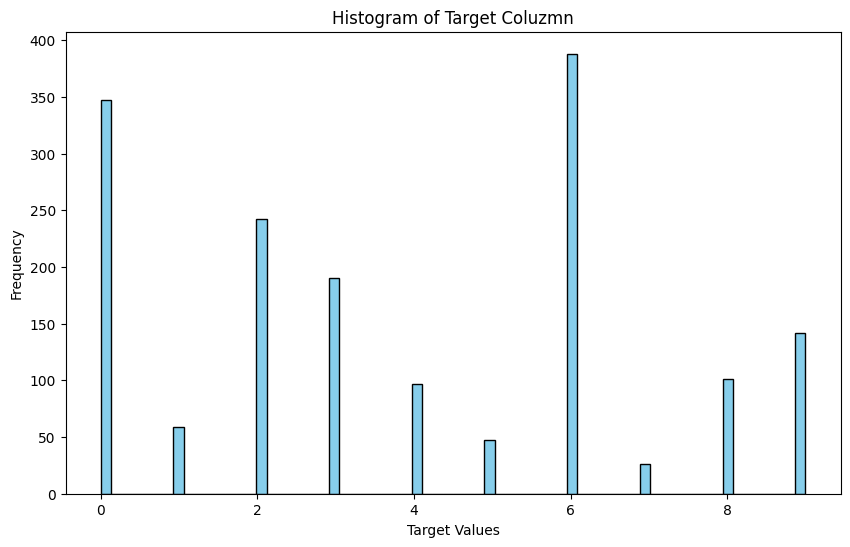

In [57]:

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [58]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
0,7138,0,2,0,0,0.791569,0.742643,0.862617,0.997068,False,True,True,True,True,True
1,3255,5,5,6,5,0.927939,0.989049,0.982203,1.000000,True,False,True,False,False,True
2,5284,6,2,6,6,0.547320,1.000000,0.999997,0.999999,False,True,True,True,True,True
3,6661,4,4,6,4,0.980549,0.941561,0.989911,0.999776,True,False,True,False,False,True
4,8824,3,5,6,5,0.617711,0.968693,0.460135,0.950391,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,6782,5,5,0,5,0.893736,0.914064,0.872910,0.997664,True,False,True,False,False,True
9996,8223,8,2,8,8,0.920552,0.996953,0.999002,0.999949,False,True,True,True,True,True
9997,6660,0,2,0,0,0.680522,0.996348,0.998283,0.999998,False,True,True,True,True,True
9998,708,8,2,8,8,0.516033,0.978006,0.980814,0.994097,False,True,True,True,True,True


In [59]:
df_results_v[(df_results_v['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
6,5151,9,3,6,3,0.821406,0.790243,0.783154,0.864123,False,False,False,False,True,False
17,9633,0,3,0,3,0.906227,0.923544,0.513635,0.851387,False,True,False,True,True,True
27,6930,2,2,0,0,0.999662,0.999953,0.697337,0.762667,True,False,False,False,False,True
69,8333,1,3,1,1,0.708226,0.861883,0.842934,0.857085,False,True,True,True,True,True
84,5794,7,3,0,0,0.413402,0.810477,0.466753,0.878399,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9973,4504,0,2,0,2,0.796180,0.878007,0.533354,0.795569,False,True,False,False,True,False
9976,7009,6,3,6,3,0.886467,0.999930,0.786021,0.598821,False,True,False,False,True,False
9983,2788,7,7,6,7,0.784033,0.925049,0.280636,0.830857,True,False,True,False,False,True
9987,1710,4,4,6,6,0.955230,0.999214,0.531005,0.709287,True,False,False,False,False,True


In [60]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag,Match_d
6,5151,9,3,6,3,0.821406,0.790243,0.783154,0.864123,False,False,False,False,True,False
98,5534,6,2,6,6,0.524291,0.999950,0.829516,0.749816,False,True,True,False,True,False
120,8041,8,3,8,3,0.705938,0.939009,0.581145,0.971140,False,True,False,False,True,False
134,972,2,3,6,6,0.369328,0.999773,0.907071,0.725246,False,False,False,True,False,False
144,8878,8,4,8,8,0.678274,0.992836,0.809973,0.990041,False,True,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9908,7059,4,4,6,6,0.964383,0.999981,0.797654,0.978883,True,False,False,True,False,False
9948,8020,6,3,6,3,0.701206,0.999153,0.677743,0.571315,False,True,False,False,True,False
9970,2377,6,4,6,6,0.965861,0.999996,0.806062,0.852387,False,True,True,False,True,False
9973,4504,0,2,0,2,0.796180,0.878007,0.533354,0.795569,False,True,False,False,True,False


In [61]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

6    91
0    76
2    61
3    54
4    28
8    21
9    19
1    10
5     9
7     6
Name: Target, dtype: int64

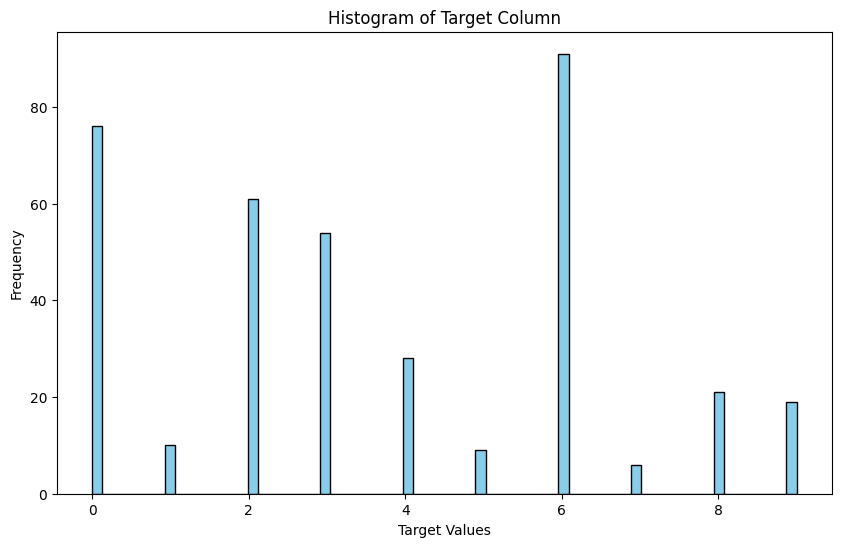

In [62]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [63]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_train_loss,total_train_accu,sum_F,sum_T


(2.8836360037231445, 0.70902, 15549, 34451)

In [64]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='softmax_tf')
total_valid_loss,total_valid_accu,sum_F,sum_T

(3.324078774833679, 0.7022, 2991, 7009)

In [65]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision,decision_mode=None):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    model_0.eval()
    model_T.eval()
    model_F.eval()
    model_decision.eval()

    with torch.no_grad():
        for data,target,decision_target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            


            for d,t in zip(data,target):
                out_d=model_decision(d.unsqueeze(0))
                _, pred= torch.max(out_d, dim = 1)

                if(decision_mode=='model'):
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                elif(decision_mode=='softmax_0'):
                    out_0=model_0(d.unsqueeze(0))
                    softmax_0 = torch.max(torch.softmax(out_0, dim=1)).item()

                    if(softmax_0<0.8):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='softmax_tf'):
                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    if(softmax_F>softmax_T):
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        outputs.append(out_T)
                        sum_T+=1

                elif(decision_mode=='model+softmax_d'):

                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))

                    softmax_d = torch.max(torch.softmax(out_d, dim=1)).item()

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    
                    if(softmax_d<0.8):
                        if(softmax_F>softmax_T):
                            outputs.append(out_F)
                            sum_F+=1
                        else:
                            outputs.append(out_T)
                            sum_T+=1
                    else:
                        if(pred==0):
                            outputs.append(model_F(d.unsqueeze(0)))
                            sum_F+=1
                        else:
                            outputs.append(model_T(d.unsqueeze(0)))
                            sum_T+=1
                elif(decision_mode=='aLL'):
                    out_F=model_F(d.unsqueeze(0))
                    out_T=model_T(d.unsqueeze(0))
                    out_0=model_0(d.unsqueeze(0))

                    softmax_d = torch.max(torch.softmax(out_d, dim=1)).item()

                    softmax_F = torch.max(torch.softmax(out_F, dim=1)).item()
                    softmax_T = torch.max(torch.softmax(out_T, dim=1)).item()
                    softmax_0 = torch.max(torch.softmax(out_0, dim=1)).item()

                    if(softmax_0<0.97):
                        if(softmax_d<0.9 and abs(softmax_F-softmax_T)>0.2):
                            if(softmax_F>softmax_T):
                                outputs.append(out_F)
                                sum_F+=1
                            else:
                                outputs.append(out_T)
                                sum_T+=1
                        elif(softmax_d>=0.9 and abs(softmax_F-softmax_T)<=0.2):
                            if(pred==0):
                                outputs.append(model_F(d.unsqueeze(0)))
                                sum_F+=1
                            else:
                                outputs.append(model_T(d.unsqueeze(0)))
                                sum_T+=1
                        else:
                            outputs.append((out_F + out_T + out_0) / 3.0)
                    else:
                        outputs.append(out_0)

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T


In [66]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision,decision_mode='model+softmax_d')
total_train_loss,total_train_accu,sum_F,sum_T

(0.7030996769833565, 0.86576, 24541, 25459)

In [67]:

total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision,decision_mode='aLL')
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.7070766637086868, 0.8445, 1517, 891)

In [68]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split}')
df

split_mode = ('classf1', [3, 5, 2, 4, 7])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.382593,0.86340,0.442443,0.8555
1,Model_Decision,0.084796,0.96720,0.103125,0.9625
2,Model_T,0.157756,0.94336,0.186107,0.9406
3,Model_F,0.427539,0.84064,0.473097,0.8344
4,Total_Model,0.703100,0.86576,0.707077,0.8445
5,Total_Model_with_perfect_decision,0.293397,0.89284,0.329602,0.8875


In [69]:
model_decision

CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.2, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.2, inplace=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (

In [70]:
# 定義鉤子函數保存指定層的輸出
def save_feature_output(module, input, output):
    global feature_output
    feature_output = output

In [71]:
def get_and_store_feature_outputs(model=model_decision,layer_idx=-1,class_number=2):
    # 選擇特定層並註冊鉤子
    layer = model.features[layer_idx]  
    hook = layer.register_forward_hook(save_feature_output)

    # 用字典按照類別儲存特徵
    category_feature_outputs = {i: [] for i in range(class_number)}  

    model.eval()  
    with torch.no_grad():
        for data, target,decision_target,idx in train_dl:
            data,target,decision_target=data.float().to(device),target.to(device),decision_target.to(device)  #將data、target放到gpu上                

            _ = model(data)

            # 获取特征层的输出
            batch_feature_output = feature_output.cpu().numpy()
            batch_feature_output = batch_feature_output.reshape(batch_feature_output.shape[0], -1)
            if(class_number==2):
                for i, label in enumerate(decision_target):
                    category_feature_outputs[label.item()].append(batch_feature_output[i])
            else:
                for i, label in enumerate(target):
                    category_feature_outputs[label.item()].append(batch_feature_output[i])
            
    # 将每个类别的特征输出拼接起来
    for category in category_feature_outputs:
        if category_feature_outputs[category]:
            category_feature_outputs[category] = np.stack(category_feature_outputs[category], axis=0)
        else:
            category_feature_outputs[category] = np.array([])

    # category_feature_outputs[0]
    # 打印每个类别的特征输出形状
    for category, features in category_feature_outputs.items():
        print(f"Category {category}: Feature output shape {features.shape}")

    # 移除钩子
    hook.remove()
    return category_feature_outputs

In [72]:
##single_feature_zero
# hist_counts = {}
# bin_edges = None
# total_samples = sum([len(category_feature_outputs[category]) for category in range(num)])

# plt.figure(figsize=(12, 8))
# colors = plt.cm.get_cmap('tab20', num)  # 使用tab20颜色，共100種颜色

# for category in range(num):
#     class_features = category_feature_outputs[category]
#     if class_features.size != 0:
#         feature_0_values = class_features[:, 0]
#         non_zero_feature_0_values = feature_0_values[feature_0_values != 0]
#         # 直方图
#         counts, bins, _ = plt.hist(feature_0_values, bins=14, alpha=0.5, label=f'Class {category}', range=(0, 1.75))
#         # # 在直方图上添加值
#         # for count, bin_edge in zip(counts, bins[:-1]):
#         #     plt.text(bin_edge, count, str(int(count)), ha='center', va='bottom')

#         hist_counts[category] = counts
#         if bin_edges is None:
#             bin_edges = bins 
#     hist_counts[category]/=total_samples       
#     # print(hist_counts[category],'---')


# delta_F = 0
# H_n_ab = np.array([hist_counts[category] for category in range(num)])
# sum_H_n_ab = np.sum(H_n_ab,axis=0)
# max_H_n_ab = np.max(H_n_ab,axis=0)
# F = sum_H_n_ab - max_H_n_ab
# delta_F=sum(F)
# print(delta_F)

# # 自定义图例
# plt.title('Distribution of Feature 0 Across All Classes')
# plt.xlabel('Feature 0 Value')
# plt.ylabel('Frequency')
# plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), ncol=1)  # 调整图例位置和布局
# plt.grid(True)
# plt.show()



In [75]:
del sum

Category 0: Feature output shape (5000, 2048)
Category 1: Feature output shape (5000, 2048)
Category 2: Feature output shape (5000, 2048)
Category 3: Feature output shape (5000, 2048)
Category 4: Feature output shape (5000, 2048)
Category 5: Feature output shape (5000, 2048)
Category 6: Feature output shape (5000, 2048)
Category 7: Feature output shape (5000, 2048)
Category 8: Feature output shape (5000, 2048)
Category 9: Feature output shape (5000, 2048)


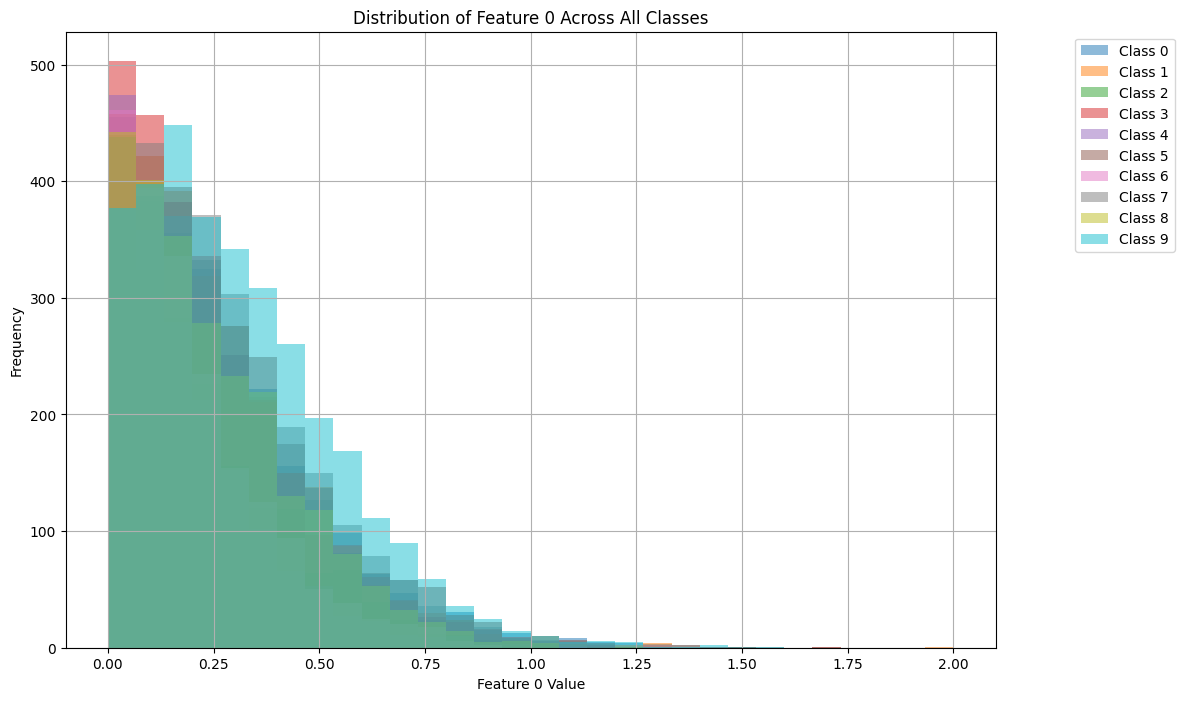

In [124]:
#single_feature_non_zero
model_0 = torch.load(f'model_{model_algo}_0_61.pth')
feature=3
num=10
hist_counts = {}
bin_edges = None
category_feature_outputs=get_and_store_feature_outputs(model=model_0,layer_idx=-1,class_number=num)
total_samples = sum([len(category_feature_outputs[category][:, feature]) for category in range(num)])

plt.figure(figsize=(12, 8))
colors = plt.cm.get_cmap('tab20', num)  # 使用tab20颜色，共100種颜色
total=0
for category in range(num):
    class_features = category_feature_outputs[category]
    if class_features.size != 0:
        feature_0_values = class_features[:, feature]
        non_zero_feature_0_values = feature_0_values[feature_0_values != 0]
        # 直方图
        counts, bins, _ = plt.hist(non_zero_feature_0_values, bins=30, alpha=0.5, label=f'Class {category}', range=(0, 2))
        # # 在直方图上添加值
        # for count, bin_edge in zip(counts, bins[:-1]):
        #     plt.text(bin_edge+0.01, count, str(int(count)), ha='center', va='bottom')
        total+=counts
        hist_counts[category] = counts
        if bin_edges is None:
            bin_edges = bins

for category in range(num):    
    hist_counts[category]/=sum(total)       
    # print(hist_counts[category],'---')


delta_F = 0
H_n_ab = np.array([hist_counts[category] for category in range(num)])
sum_H_n_ab = np.sum(H_n_ab,axis=0)
max_H_n_ab = np.max(H_n_ab,axis=0)
F = sum_H_n_ab - max_H_n_ab
delta_F=sum(F)
# print(delta_F)

# 自定义图例
plt.title('Distribution of Feature 0 Across All Classes')
plt.xlabel('Feature 0 Value')
plt.ylabel('Frequency')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), ncol=1)  # 调整图例位置和布局
plt.grid(True)
plt.show()



Category 0: Feature output shape (25000, 2048)
Category 1: Feature output shape (25000, 2048)


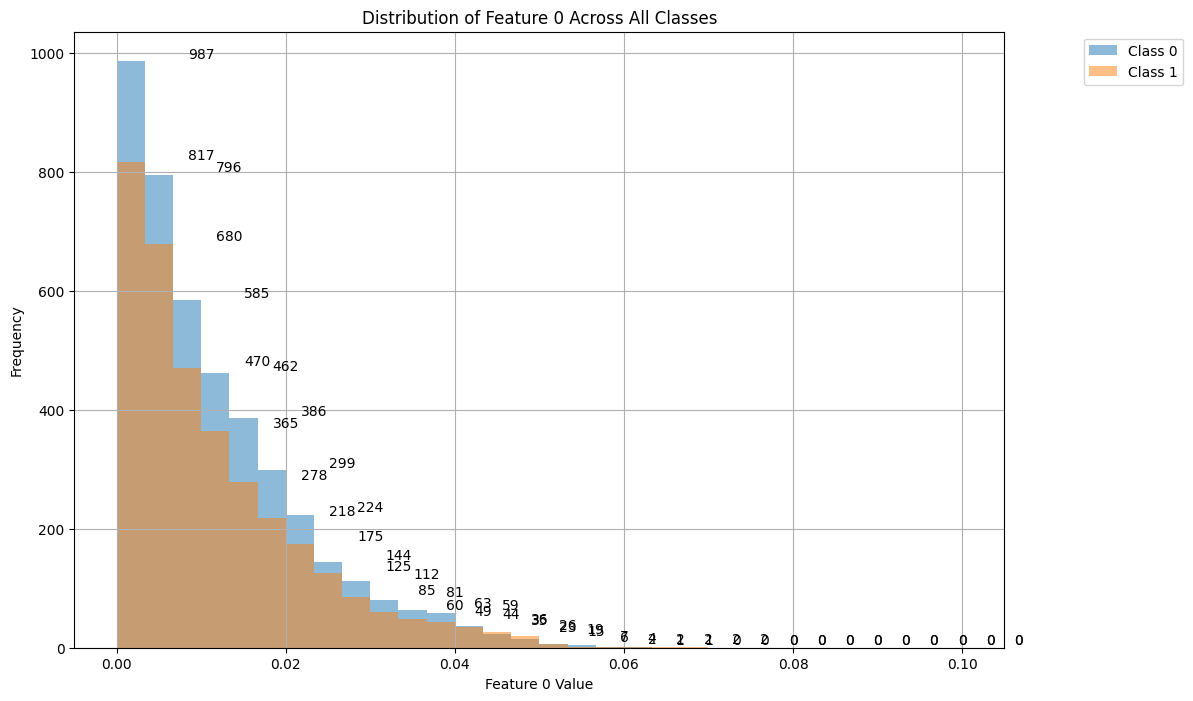

In [123]:
#single_feature_non_zero
model_decision = torch.load(f'model_{model_algo}_decision_15.pth')
feature=15
num=2
hist_counts = {}
bin_edges = None
category_feature_outputs=get_and_store_feature_outputs(model=model_decision,layer_idx=-1,class_number=num)
total_samples = sum([len(category_feature_outputs[category][:, feature]) for category in range(num)])

plt.figure(figsize=(12, 8))
colors = plt.cm.get_cmap('tab20', num)  # 使用tab20颜色，共100種颜色
total=0
for category in range(num):
    class_features = category_feature_outputs[category]
    if class_features.size != 0:
        feature_0_values = class_features[:, feature]
        non_zero_feature_0_values = feature_0_values[feature_0_values != 0]
        # 直方图
        counts, bins, _ = plt.hist(non_zero_feature_0_values, bins=30, alpha=0.5, label=f'Class {category}', range=(0, 0.1))
        # 在直方图上添加值
        for count, bin_edge in zip(counts, bins[:-1]):
            plt.text(bin_edge+0.01, count, str(int(count)), ha='center', va='bottom')
        total+=counts
        hist_counts[category] = counts
        if bin_edges is None:
            bin_edges = bins

for category in range(num):    
    hist_counts[category]/=sum(total)       
    # print(hist_counts[category],'---')


delta_F = 0
H_n_ab = np.array([hist_counts[category] for category in range(num)])
sum_H_n_ab = np.sum(H_n_ab,axis=0)
max_H_n_ab = np.max(H_n_ab,axis=0)
F = sum_H_n_ab - max_H_n_ab
delta_F=sum(F)
# print(delta_F)

# 自定义图例
plt.title('Distribution of Feature 0 Across All Classes')
plt.xlabel('Feature 0 Value')
plt.ylabel('Frequency')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), ncol=1)  # 调整图例位置和布局
plt.grid(True)
plt.show()



In [84]:
#non_zero
def calculate_feature_selection(category_feature_outputs, num_classes=2, threshold=0.1):

    total_samples = sum([len(category_feature_outputs[category]) for category in range(num_classes)])
    num_features = category_feature_outputs[0].shape[1]  

    delta_F_all_features = []

    for feature_idx in range(num_features):
        hist_counts = {}
        bin_edges = None
        total=0
        for category in range(num_classes):
            class_features = category_feature_outputs[category]
            if class_features.size != 0:
                feature_values = class_features[:, feature_idx]
                non_zero_feature_values= feature_values[feature_values != 0]
                
                # 直方图
                counts, bins = np.histogram(non_zero_feature_values, bins=30)
                total+=counts
              
                hist_counts[category] = counts
                if bin_edges is None:
                    bin_edges = bins  

        for category in range(num_classes):    
            hist_counts[category] = hist_counts[category] / (sum(total)+1)  
            # print(hist_counts[category])
        # 公式 7
        delta_F = 0
        H_n_ab = np.array([hist_counts[category] for category in range(num_classes)])
        sum_H_n_ab = np.sum(H_n_ab, axis=0)
        max_H_n_ab = np.max(H_n_ab, axis=0)
        F = sum_H_n_ab - max_H_n_ab
        delta_F = sum(F)

        delta_F_all_features.append(delta_F)

    print("Δ(F_it^N) for all features:", delta_F_all_features)
    delta_F_all_features = np.array(delta_F_all_features)
    selected_feature_indices = np.where((delta_F_all_features < threshold) & (delta_F_all_features != 0))[0]
    return delta_F_all_features,selected_feature_indices

In [85]:
# #zero
# total_samples = sum([len(category_feature_outputs[category]) for category in range(10)])
# num_features = category_feature_outputs[0].shape[1]  

# delta_F_all_features = []
# total=0
# for feature_idx in range(num_features):
#     hist_counts = {}
#     bin_edges = None

#     for category in range(10):
#         class_features = category_feature_outputs[category]
#         if class_features.size != 0:
#             feature_values = class_features[:, feature_idx]
#             non_zero_feature_0_values = feature_0_values[feature_0_values != 0]
#             # 直方图
#             counts, bins = np.histogram(feature_values, bins=14)
#             # print(counts)
#             hist_counts[category] = counts
#             if bin_edges is None:
#                 bin_edges = bins  
        
#         hist_counts[category] = hist_counts[category] / total_samples  
    
#     # 公式 7
#     delta_F = 0
#     H_n_ab = np.array([hist_counts[category] for category in range(10)])
#     sum_H_n_ab = np.sum(H_n_ab, axis=0)
#     max_H_n_ab = np.max(H_n_ab, axis=0)
#     F = sum_H_n_ab - max_H_n_ab
#     delta_F = sum(F)

#     delta_F_all_features.append(delta_F)

# print("Δ(F_it^N) for all features:", delta_F_all_features)


In [86]:
class CNNModelWithFeatureSelection(nn.Module):
    def __init__(self, original_model, selected_feature_indices):
        super(CNNModelWithFeatureSelection, self).__init__()
        self.features = original_model.features
        self.classifier = original_model.classifier

        # 保存选择的特征索引
        self.selected_feature_indices = selected_feature_indices
        
        self.classifier[1]=nn.Linear(len(self.selected_feature_indices), 1024)

        # 定义最后一层特征提取层的索引
        self.feature_layer_index = 16
        
    def forward(self, x):
        # 经过特征提取层
        for i, layer in enumerate(self.features):
            x = layer(x)
            if i == self.feature_layer_index:
                feature_output = x

        # 获取特征输出并进行特征选择
        batch_feature_output = feature_output.view(feature_output.size(0), -1)
        selected_features = batch_feature_output[:, self.selected_feature_indices]
            
        # 将选择的特征重塑为适合分类器输入的形状
        x = selected_features
        
        # 经过分类器层
        x = self.classifier(x)
        return x

In [93]:
category_feature_outputs=get_and_store_feature_outputs(model=model_0,layer_idx=-1,class_number=10)
delta_F_all_features,selected_feature_indices=calculate_feature_selection(category_feature_outputs, num_classes=10, threshold=0.8)

Category 0: Feature output shape (5000, 2048)
Category 1: Feature output shape (5000, 2048)
Category 2: Feature output shape (5000, 2048)
Category 3: Feature output shape (5000, 2048)
Category 4: Feature output shape (5000, 2048)
Category 5: Feature output shape (5000, 2048)
Category 6: Feature output shape (5000, 2048)
Category 7: Feature output shape (5000, 2048)
Category 8: Feature output shape (5000, 2048)
Category 9: Feature output shape (5000, 2048)
Δ(F_it^N) for all features: [0.8336521818347454, 0.8322824716267337, 0.8296146044624748, 0.8530178382340962, 0.7620504037191096, 0.7312973970075834, 0.7539018503620274, 0.8101029562285508, 0.8013343955387371, 0.7271151885830788, 0.7439764111204714, 0.8041068720102674, 0.8210341365461846, 0.7955911823647295, 0.785267603346057, 0.8151637943660595, 0.8301435406698563, 0.6794081381011096, 0.680113100848256, 0.7359820570330023, 0.8095308350545883, 0.7837290774620472, 0.7778619123012321, 0.757740414189051, 0.7835820895522386, 0.764138206910

In [94]:
len(selected_feature_indices)

658

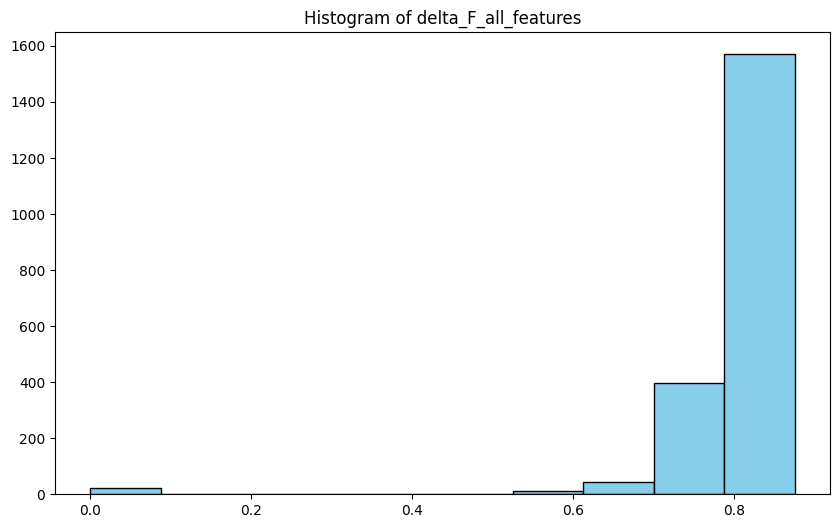

In [92]:
plt.figure(figsize=(10, 6))
plt.hist(delta_F_all_features, color='skyblue', edgecolor='black')
plt.title('Histogram of delta_F_all_features')
plt.show()

Epoch=0,train_loss=0.7039444951438903,train_accu=75.22999999999999%
Epoch=0,valid_loss=0.6507320850849152,valid_accu=77.81%
0
Epoch=1,train_loss=0.6175337426185608,train_accu=78.304%
Epoch=1,valid_loss=0.5847868251800538,valid_accu=79.79%
0
Epoch=2,train_loss=0.5952975993156433,train_accu=79.12%
Epoch=2,valid_loss=0.5529972676277161,valid_accu=80.88%
0
Epoch=3,train_loss=0.5754502091217041,train_accu=79.908%
Epoch=3,valid_loss=0.5399064479827881,valid_accu=81.15%
0
Epoch=4,train_loss=0.5591854641819001,train_accu=80.64%
Epoch=4,valid_loss=0.5345946259975434,valid_accu=81.6%
0
Epoch=5,train_loss=0.5525893878221512,train_accu=80.72200000000001%
Epoch=5,valid_loss=0.52100992603302,valid_accu=82.14%
0
Epoch=6,train_loss=0.5576126252555847,train_accu=80.444%
Epoch=6,valid_loss=0.5366498517036438,valid_accu=81.81%
EarlyStopping counter: 1 out of 5
Epoch=7,train_loss=0.5353329210281372,train_accu=81.316%
Epoch=7,valid_loss=0.5165326333999634,valid_accu=82.16%
0
Epoch=8,train_loss=0.5479214926

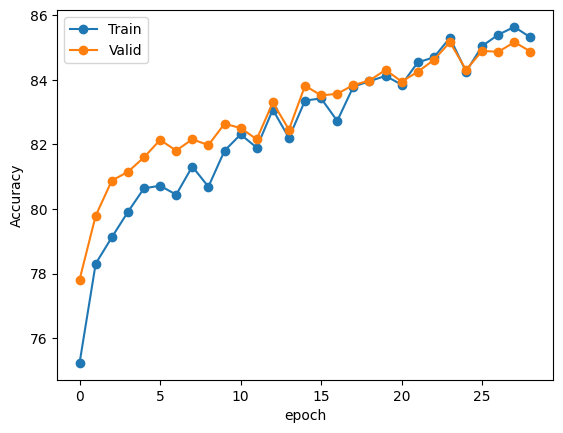

In [97]:
model_00=CNNModelWithFeatureSelection(model_0,selected_feature_indices)
optim = torch.optim.Adam(model_00.parameters(), lr=1e-4, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss() 
model_00=trainer(100,model_00,criterion,optim,train_dl,valid_dl,'00',model_algo)

In [ ]:
# model_decision=torch.load(f'model_{model_algo}_decision_24.pth')

In [103]:
category_feature_outputs=get_and_store_feature_outputs(model=model_decision,layer_idx=-1,class_number=2)
delta_F_all_features,selected_feature_indices=calculate_feature_selection(category_feature_outputs, num_classes=2, threshold=0.4)

Category 0: Feature output shape (25000, 2048)
Category 1: Feature output shape (25000, 2048)
Δ(F_it^N) for all features: [0.44333432746793927, 0.42645118733509235, 0.4212724364670339, 0.43198102485546286, 0.37685088633993746, 0.3992954324586978, 0.3987848394252097, 0.3470075187969925, 0.30176169729115365, 0.3209591883790637, 0.3097047225161105, 0.29685975084677657, 0.2919738960928893, 0.3396436525612471, 0.33839786835988434, 0.4177455211193932, 0.37929275756545394, 0.42718846549948514, 0.38997517070142784, 0.4056922334780512, 0.4573198368333583, 0.3199756209050738, 0.30952999220981575, 0.2734051367025684, 0.3914897741591547, 0.2592397876031755, 0.2520348422104811, 0.22037767171612369, 0.4678470824949699, 0.3832810599756769, 0.34971910112359544, 0.41135793113247754, 0.34654994850669396, 0.27471206810215326, 0.2924180532031484, 0.4180855630276148, 0.44692808787840077, 0.428145066473727, 0.44740833258988316, 0.3476041304095604, 0.2976726726726727, 0.36858515210246895, 0.33999531579358266

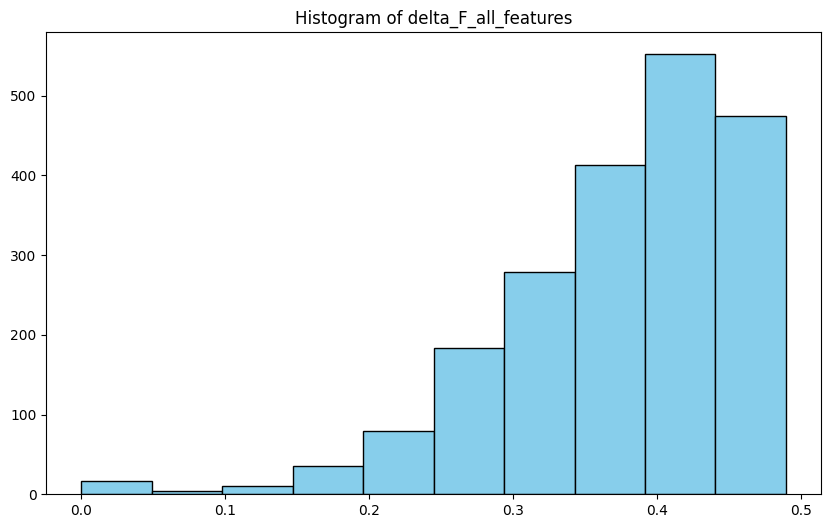

In [104]:
plt.figure(figsize=(10, 6))
plt.hist(delta_F_all_features, color='skyblue', edgecolor='black')
plt.title('Histogram of delta_F_all_features')
plt.show()

In [105]:
len(selected_feature_indices)

1095

Epoch=0,train_loss=0.15446913502812384,train_accu=93.81%
Epoch=0,valid_loss=0.14817792575657368,valid_accu=94.05%
0
Epoch=1,train_loss=0.1503576350915432,train_accu=93.904%
Epoch=1,valid_loss=0.15197046090066432,valid_accu=94.3%
0
Epoch=2,train_loss=0.12625727136075496,train_accu=94.982%
Epoch=2,valid_loss=0.12825086814910172,valid_accu=95.19999999999999%
0
Epoch=3,train_loss=0.12820838444411756,train_accu=94.876%
Epoch=3,valid_loss=0.13129058645963668,valid_accu=94.93%
EarlyStopping counter: 1 out of 5
Epoch=4,train_loss=0.11447993017405271,train_accu=95.542%
Epoch=4,valid_loss=0.12404451973885298,valid_accu=95.47%
0
Epoch=5,train_loss=0.1303466663813591,train_accu=94.738%
Epoch=5,valid_loss=0.1300914506047964,valid_accu=94.89999999999999%
EarlyStopping counter: 1 out of 5
Epoch=6,train_loss=0.1114216092813015,train_accu=95.57%
Epoch=6,valid_loss=0.1272142627030611,valid_accu=95.12%
EarlyStopping counter: 2 out of 5
Learning rate reduced by 10%8e-05
Epoch=7,train_loss=0.10556462625563

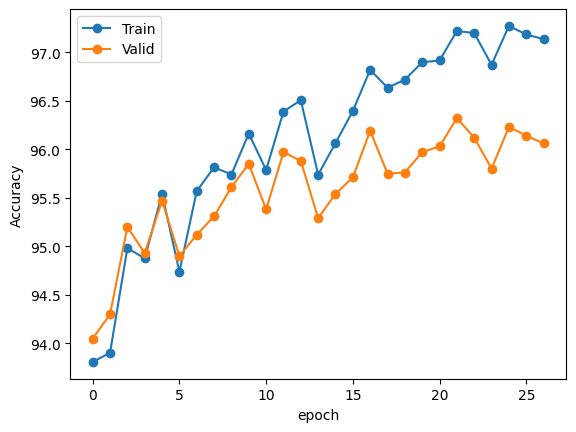

In [106]:
model_dd=CNNModelWithFeatureSelection(model_decision,selected_feature_indices)
optim = torch.optim.Adam(model_dd.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss() 
model_dd=trainer(100,model_dd,criterion,optim,train_dl,valid_dl,'decision',model_algo)

In [107]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_dd,decision_mode='model')
total_train_loss,total_train_accu,sum_F,sum_T

(0.5795341658639908, 0.86986, 25155, 24845)

In [108]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_dd,decision_mode='model')
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.745728137075901, 0.8587, 4998, 5002)

In [109]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [110]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split}')
df

split_mode = ('classf1', [3, 5, 2, 4, 7])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.382593,0.86340,0.442443,0.8555
1,Model_Decision,0.084796,0.96720,0.103125,0.9625
2,Model_T,0.157756,0.94336,0.186107,0.9406
3,Model_F,0.427539,0.84064,0.473097,0.8344
4,Total_Model,0.579534,0.86986,0.745728,0.8587
5,Total_Model_with_perfect_decision,0.293397,0.89284,0.329602,0.8875


In [111]:
class CNNModelWithFeatureSelection(nn.Module):
    def __init__(self, original_model, selected_feature_indices):
        super(CNNModelWithFeatureSelection, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

        # 保存选择的特征索引
        self.selected_feature_indices = selected_feature_indices
        
        self.classifier[1]=nn.Linear(len(self.selected_feature_indices), 1024)

        # 定义最后一层特征提取层的索引
        self.feature_layer_index = 16
        
    def forward(self, x):
        # 经过特征提取层
        for i, layer in enumerate(self.features):
            x = layer(x)
            if i == self.feature_layer_index:
                feature_output = x

        # 获取特征输出并进行特征选择
        batch_feature_output = feature_output.view(feature_output.size(0), -1)
        selected_features = batch_feature_output[:, self.selected_feature_indices]
            
        # 将选择的特征重塑为适合分类器输入的形状
        x = selected_features
        
        # 经过分类器层
        x = self.classifier(x)
        return x

Epoch=0,train_loss=0.4180534296607971,train_accu=81.43%
Epoch=0,valid_loss=0.3927267844438553,valid_accu=82.58%
0
Epoch=1,train_loss=0.38310669013500215,train_accu=82.696%
Epoch=1,valid_loss=0.3471164137125015,valid_accu=84.43%
0
Epoch=2,train_loss=0.3358249776220322,train_accu=85.44800000000001%
Epoch=2,valid_loss=0.3347014377832413,valid_accu=85.8%
0
Epoch=3,train_loss=0.32537646909713747,train_accu=85.922%
Epoch=3,valid_loss=0.3229720567703247,valid_accu=86.14%
0
Epoch=4,train_loss=0.2987219711589813,train_accu=87.024%
Epoch=4,valid_loss=0.2856412814378738,valid_accu=87.67%
0
Epoch=5,train_loss=0.29064275254726407,train_accu=87.524%
Epoch=5,valid_loss=0.2694899955749512,valid_accu=88.29%
0
Epoch=6,train_loss=0.2690479657125473,train_accu=88.68599999999999%
Epoch=6,valid_loss=0.25621729991436004,valid_accu=89.05999999999999%
0
Epoch=7,train_loss=0.25954463295459745,train_accu=89.072%
Epoch=7,valid_loss=0.24453996831178665,valid_accu=89.46%
0
Epoch=8,train_loss=0.24857924072027207,tra

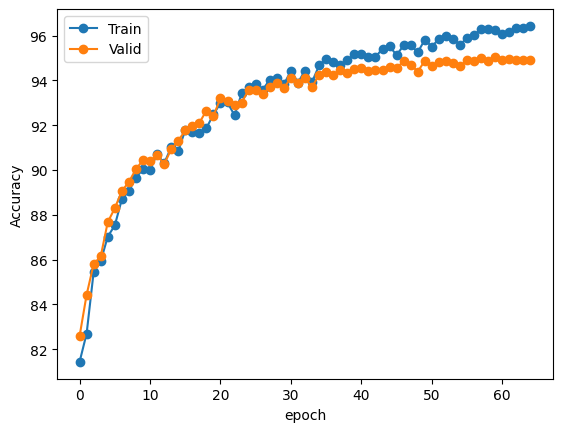

In [112]:
model_dd=CNNModelWithFeatureSelection(model_decision,selected_feature_indices)
optim = torch.optim.Adam(model_dd.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss() 
model_dd=trainer(100,model_dd,criterion,optim,train_dl,valid_dl,'decision',model_algo)